# EDA and Deep-Dive on Clinic Appointments

## Section 1: Data Loading and Descriptive Stats

In [1]:
# Import needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load clinic_appointements.csv into dataframe
raw_df = pd.read_csv(
    'case_study/clinic_appointments.csv',
    parse_dates=['ScheduledDay', 'AppointmentDay']
)

# Print dataframe shape and first 5 rows for manual inspection
print(f'Rows: {len(raw_df):,}  Columns: {raw_df.shape[1]}')
raw_df.head()

Rows: 110,527  Columns: 14


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Clinic,LowIncome,Hypertension,Diabetes,SubstanceUseDisorder,Disability,SMSReminder,NoShow
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,Riverside Commons,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,Riverside Commons,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,Shoreline Bluff,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,Peninsula Point,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,Riverside Commons,0,1,1,0,0,0,No


In [3]:
# Print out data types of the 14 columns
raw_df.dtypes

PatientId                           float64
AppointmentID                         int64
Gender                               object
ScheduledDay            datetime64[ns, UTC]
AppointmentDay          datetime64[ns, UTC]
Age                                   int64
Clinic                               object
LowIncome                             int64
Hypertension                          int64
Diabetes                              int64
SubstanceUseDisorder                  int64
Disability                            int64
SMSReminder                           int64
NoShow                               object
dtype: object

In [4]:
# Print descriptive stats on each of the 14 columns
raw_df.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Clinic,LowIncome,Hypertension,Diabetes,SubstanceUseDisorder,Disability,SMSReminder,NoShow
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,NaN,NaN,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,NaN,NaN,NaN,Greenwood Village,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,NaN,NaN,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,2016-05-09 07:49:15.846273024+00:00,2016-05-19 00:57:50.008233472+00:00,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
min,3.921784e+04,5.030230e+06,NaN,2015-11-10 07:13:56+00:00,2016-04-29 00:00:00+00:00,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,2016-04-29 10:27:01+00:00,2016-05-09 00:00:00+00:00,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,2016-05-10 12:13:17+00:00,2016-05-18 00:00:00+00:00,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,2016-05-20 11:18:37+00:00,2016-05-31 00:00:00+00:00,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
max,9.999816e+14,5.790484e+06,NaN,2016-06-08 20:07:23+00:00,2016-06-08 00:00:00+00:00,115.000000,NaN,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,NaN


In [5]:
# Print null counts by each of the 14 columns
raw_df.isnull().sum()

PatientId               0
AppointmentID           0
Gender                  0
ScheduledDay            0
AppointmentDay          0
Age                     0
Clinic                  0
LowIncome               0
Hypertension            0
Diabetes                0
SubstanceUseDisorder    0
Disability              0
SMSReminder             0
NoShow                  0
dtype: int64


### Notes
Based on the output of the above, we can come up with some rough initial conjectures:

1) PatientId was likely misread as a float

2) The dataset is skewed significantly Female (F)

3) AppointmentDay could have a timestamp issue (maybe coincidence but quartiles all seem set to midnight)

4) The value range for Age needs to be inspected as the min = -1 seems wrong (maybe it's for a fetal appointment?)

5) Clinic has 81 unique values with Greenwood Village representing roughly 7% of the dataset

6) LowIncome, Hypertension, Diabetes, SubstanceUserDisorder, Disability SMSReminder look like flags given that they're int64 and the min/max are in the 0-1 range (likely 1 = Yes, 0 = No)

7) Disability doesn't seem to be a flag as the max = 4 indicates something else (ordinal or count?)

8) NoShow is a stringified boolean (as per the instructions) and the data contains mostly successful appointments (No > Yes)

Let's dive deeper into each column so we can understand 1) the distribution of its values and 2) patterns as they relate to the other columns 

## Section 2: Column Value Distribution and Cross-Analysis

### PatientId

In [6]:
# Check whether PatientId values are all whole numbers
col = raw_df['PatientId']
has_fractional = (col % 1 != 0).sum()
print(f"PatientId dtype: {col.dtype}")
print(f"Values with fractional part: {has_fractional:,} ({has_fractional / len(col):.2%})")
print(f"  → PatientId {'can' if has_fractional == 0 else 'CANNOT'} be safely cast to integer")

# Count unique PatientId values (keep as float — no lossless int cast possible if fractional values exist)
n_unique = col.nunique()
print(f"\nUnique PatientId values: {n_unique:,}")

PatientId dtype: float64
Values with fractional part: 5 (0.00%)
  → PatientId CANNOT be safely cast to integer

Unique PatientId values: 62,299


In [7]:
# Inspect the 5 rows where PatientId has a fractional part
fractional_mask = raw_df['PatientId'] % 1 != 0
print(f"Rows with fractional PatientId: {fractional_mask.sum()}")
raw_df[fractional_mask][['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Clinic']]

Rows with fractional PatientId: 5


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Clinic
3950,93779.52927,5712759,F,2016-05-18 09:12:29+00:00,2016-05-18 00:00:00+00:00,33,Downtown Central
73228,537615.28476,5637728,F,2016-04-29 07:19:57+00:00,2016-05-06 00:00:00+00:00,14,Fort Hamilton
73303,141724.16655,5637648,M,2016-04-29 07:13:36+00:00,2016-05-02 00:00:00+00:00,12,Fort Hamilton
100517,39217.84439,5751990,F,2016-05-31 10:56:41+00:00,2016-06-03 00:00:00+00:00,44,Bayside Promenade
105430,43741.75652,5760144,M,2016-06-01 14:22:58+00:00,2016-06-01 00:00:00+00:00,39,Maplewood Heights


Manually inspecting this against the raw data in clinic_appointments.csv shows that it is in fact fractional with the addition of E-5 at the end of these values.

Given that the vast majority of the values in the column are integers without similar issue and without any discernible pattern across the other columns, it's very likely that this was an intermittent system error and the errant decimal point can simply be removed. 

However, I'm also curious to see if these patients were pre-existing and which can corroborate the intermittent system theory.

In [8]:
# For each fractional PatientId, derive the "decimal-removed" integer ID by:
# Treating the raw float string and stripping the '.' (e.g. 12345.6 → 123456)
# Then checking if this matches any other row in the dataset.

fractional_rows = raw_df[fractional_mask].copy()

results = []
for _, row in fractional_rows.iterrows():
    raw_val = row['PatientId']
    str_id = float(str(raw_val).replace('.', ''))
    str_matches   = raw_df[raw_df['PatientId'] == str_id].drop(index=row.name, errors='ignore')

    results.append({
        'raw_PatientId':       raw_val,
        'str_removed_id':      str_id,
        'str_removed_matches': len(str_matches),
    })

import pandas as pd
results_df = pd.DataFrame(results)
print("Fractional PatientId — match search results:")
results_df

Fractional PatientId — match search results:


,raw_PatientId,str_removed_id,str_removed_matches
0,93779.52927,9.377953e+09,0
1,537615.28476,5.376153e+10,0
2,141724.16655,1.417242e+10,0
3,39217.84439,3.921784e+09,0
4,43741.75652,4.374176e+09,0


No matches, but at least we checked to make sure in case they were exisitng patients and their other patient data (.e.g age, clinic, etc) lined up.

Still very likely that for the aforementioned reasons, this set of 5 PatientId values were incorrectly inputted due to some ephemeral systemic issue and should therefore be cleaned in a similar manner as demonstrated above for production.

As a final check, let's look at the number of appointments by patients as well as the average interval time between them.

In [9]:

# Per-patient mean interval (days between consecutive appointments)
patient_intervals = (
    raw_df.sort_values(['PatientId', 'AppointmentDay'])
    .groupby('PatientId')['AppointmentDay']
    .apply(lambda x: x.diff().dt.days.mean())  # Will be null for single-appt patients
    .reset_index(name='mean_interval_days')
)

appt_counts = (
    raw_df['PatientId'].value_counts()
    .reset_index()
    .rename(columns={'PatientId': 'PatientId', 'count': 'Appointments'})
)

summary = (
    appt_counts
    .merge(patient_intervals, on='PatientId')
    .groupby('Appointments')
    .agg(
        **{'Number of Patients': ('PatientId', 'count'),
            'Avg Interval (days)': ('mean_interval_days', 'mean')}
    )
    .round({'Avg Interval (days)': 1})
    .reset_index()
)
summary

,Appointments,Number of Patients,Avg Interval (days)
0,1,37920,NaN
1,2,13895,12.4
2,3,5500,9.7
3,4,2367,7.7
4,5,1119,6.4
5,6,553,5.6
6,7,306,4.9
7,8,202,4.3
8,9,104,3.9
9,10,85,3.6


Kind of wild that someone has 88 appointments in what looks to be a 7-month scheduling span accoridng to the descriptive stats above. Let's dive in that particular patient to see if there's anything else we should be paying attention to as well go along in the rest of the notebook. 

In [10]:
# Find the PatientId with 88 appointments
patient_88 = raw_df['PatientId'].value_counts().idxmax()
patient_88 = raw_df['PatientId'].value_counts()[raw_df['PatientId'].value_counts() == 88].index[0]

print(f"PatientId: {patient_88}")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
raw_df[raw_df['PatientId'] == patient_88].sort_values('AppointmentDay')

PatientId: 822145925426128.0


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Clinic,LowIncome,Hypertension,Diabetes,SubstanceUseDisorder,Disability,SMSReminder,NoShow
3006,8.221459e+14,5638995,M,2016-04-29 08:38:44+00:00,2016-04-29 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
3060,8.221459e+14,5642878,M,2016-04-29 18:02:42+00:00,2016-04-29 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
3093,8.221459e+14,5640809,M,2016-04-29 11:27:34+00:00,2016-04-29 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
35675,8.221459e+14,5649163,M,2016-05-02 17:57:36+00:00,2016-05-02 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
25428,8.221459e+14,5649058,M,2016-05-02 17:38:17+00:00,2016-05-02 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
8707,8.221459e+14,5645183,M,2016-05-02 09:34:46+00:00,2016-05-02 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
7685,8.221459e+14,5655382,M,2016-05-03 16:57:59+00:00,2016-05-03 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
8465,8.221459e+14,5658733,M,2016-05-04 11:40:14+00:00,2016-05-04 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
25421,8.221459e+14,5660730,M,2016-05-04 18:08:30+00:00,2016-05-04 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No
25412,8.221459e+14,5660677,M,2016-05-04 17:22:49+00:00,2016-05-04 00:00:00+00:00,38,Edgewood Station,0,0,0,0,0,0,No


While this may seem incredulous at first, it does also seem possible that each appointment may be a fast follow-up with a chronically ill patient receiving intense treatment. There's 0 no-shows despite the sometimes multiple appointments in a day mere hours apart. I think this may be worth revisiting in the clinic section to understand if we see this behavior at other clinics.

## AppointmentId

In [11]:
# Count unique AppointmentID values
n_unique_appt = raw_df['AppointmentID'].nunique()
total_rows = len(raw_df)
print(f"Total rows:               {total_rows:,}")
print(f"Unique AppointmentID values: {n_unique_appt:,}")
print(f"Duplicates: {total_rows - n_unique_appt:,}")

Total rows:               110,527
Unique AppointmentID values: 110,527
Duplicates: 0


Given that this matches the total length of the dataframe and that PatientId above only have ~63k unique values, we can assume that this column is the true grain of the table. 

As such, we'll need to decide on how to best model and capture changes in the PatientId column over time with either a dedicated dimension table of the SCD2 variety (so that we can track patient history and be able to refer to their records based on a particular point-in-time) or acknowledging that this is actually the only source of patient data with the implicit assumption that it only gets udpated at appointment time and therefore it makes sense to keep it in the same table à la OBT (we could also still grab point in time records with a query with WHERE date filter, ORDER BY, and LIMIT 1 clauses as a workaround depending on the case).

Before presenting the final argument for either, we should check if patient records are updated at scheduling time or appointment time. A simple way to do this is to look at patients with multiple appointments which resulted in both attendance and no-shows and see how the attributes differ.

In [12]:
# Isolate patients with exactly 2 appointments: first = attended (No), second = no-show (Yes)
# Then compare attributes between the two visits

attr_cols = ['Age', 'LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Disability']

two_appt = (
    raw_df.groupby('PatientId')
    .filter(lambda x: len(x) == 2)
    .sort_values(['PatientId', 'AppointmentDay'])
)

rows = []
for patient_id, grp in two_appt.groupby('PatientId'):
    grp = grp.reset_index(drop=True)
    if grp.iloc[0]['NoShow'] == 'No' and grp.iloc[1]['NoShow'] == 'Yes':
        first, second = grp.iloc[0], grp.iloc[1]
        diffs = {c: second[c] - first[c] for c in attr_cols}
        rows.append({
            'PatientId': patient_id,
            'any_change': any(d != 0 for d in diffs.values()),
            **{f'diff_{c}': diffs[c] for c in attr_cols},
        })

result_df = pd.DataFrame(rows)
total = len(result_df)
changed = result_df['any_change'].sum()

print(f"Patients matching pattern (show → no-show): {total:,}")
print(f"With at least one attribute change:         {changed:,} ({changed/total:.1%})")
print(f"With identical attributes across both:      {total - changed:,} ({(total-changed)/total:.1%})")
print()
print("Attribute-level differences (non-zero count):")
diff_cols = [c for c in result_df.columns if c.startswith('diff_')]
print(result_df[diff_cols].ne(0).sum().rename(lambda x: x.replace('diff_', '')).rename("Patients with change"))

Patients matching pattern (show → no-show): 2,114
With at least one attribute change:         82 (3.9%)
With identical attributes across both:      2,032 (96.1%)

Attribute-level differences (non-zero count):
Age                     82
LowIncome                0
Hypertension             0
Diabetes                 0
SubstanceUseDisorder     0
Disability               0
Name: Patients with change, dtype: int64


It's interesting that the attributes don't really change except for age. However, the mere fact that age _does_ change at all does seem to posit that attributes are recorded independently at each appointment and not just copied forward if there's a no-show. The fact that the non-age attributes do not change here can be explained by the real-world empirical fact that socio-economic status and diseases tend to be sticky and do not change quickly.

Let's look at patients with consecutive attendance to see if the same pattern holds up...

In [13]:
# Isolate patients with exactly 2 appointments: first = attended (No), second = attended (No)
# Then compare attributes between the two visits

attr_cols = ['Age', 'LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Disability']

two_appt = (
    raw_df.groupby('PatientId')
    .filter(lambda x: len(x) == 2)
    .sort_values(['PatientId', 'AppointmentDay'])
)

rows = []
for patient_id, grp in two_appt.groupby('PatientId'):
    grp = grp.reset_index(drop=True)
    if grp.iloc[0]['NoShow'] == 'No' and grp.iloc[1]['NoShow'] == 'No':
        first, second = grp.iloc[0], grp.iloc[1]
        diffs = {c: second[c] - first[c] for c in attr_cols}
        rows.append({
            'PatientId': patient_id,
            'any_change': any(d != 0 for d in diffs.values()),
            **{f'diff_{c}': diffs[c] for c in attr_cols},
        })

result_df = pd.DataFrame(rows)
total = len(result_df)
changed = result_df['any_change'].sum()

print(f"Patients matching pattern (show → show): {total:,}")
print(f"With at least one attribute change:         {changed:,} ({changed/total:.1%})")
print(f"With identical attributes across both:      {total - changed:,} ({(total-changed)/total:.1%})")
print()
print("Attribute-level differences (non-zero count):")
diff_cols = [c for c in result_df.columns if c.startswith('diff_')]
print(result_df[diff_cols].ne(0).sum().rename(lambda x: x.replace('diff_', '')).rename("Patients with change"))

Patients matching pattern (show → show): 8,980
With at least one attribute change:         287 (3.2%)
With identical attributes across both:      8,693 (96.8%)

Attribute-level differences (non-zero count):
Age                     287
LowIncome                 0
Hypertension              0
Diabetes                  0
SubstanceUseDisorder      0
Disability                0
Name: Patients with change, dtype: int64


The pattern holds, but maybe all this just means that not enough time is elapsing for these people?

Let's include some customers with much longer patient appointment histories and hone in on those pairs with longer intervals between appointments to be sure.

Patients with 3+ appointments: 10,484

no-show → attended pairs with interval > 20 days: 374
With at least one non-Age attribute change:        0 (0.0%)
Identical attributes:                              374 (100.0%)
Max elapsed days: 40

                 pairs  attr_changes  pct_changed
interval_bucket                                  
31–41d              43             0          0.0


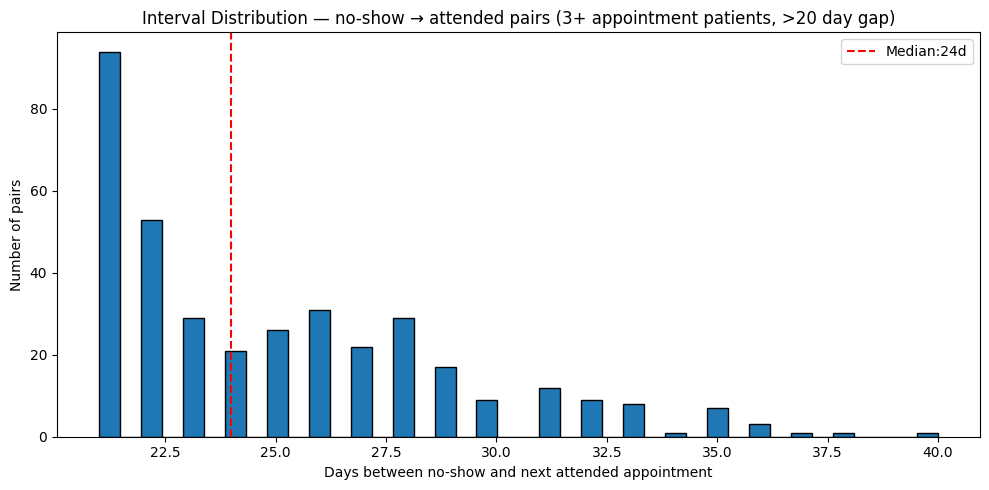

In [14]:
# For patients with 3+ appointments, find consecutive no-show → attended pairs with intervals > 20 days, and plot a histogram of those intervals

attr_cols_no_age = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Disability']

three_plus = (
    raw_df.groupby('PatientId')
    .filter(lambda x: len(x) >= 3)
    .sort_values(['PatientId', 'AppointmentDay'])
)

print(f"Patients with 3+ appointments: {three_plus['PatientId'].nunique():,}")

rows = []
for patient_id, grp in three_plus.groupby('PatientId'):
    grp = grp.reset_index(drop=True)
    for i in range(1, len(grp)):
        prev, curr = grp.iloc[i - 1], grp.iloc[i]
        if prev['NoShow'] == 'Yes' and curr['NoShow'] == 'No':
            elapsed = (curr['AppointmentDay'] - prev['AppointmentDay']).days
            if elapsed > 20:
                diffs = {c: curr[c] - prev[c] for c in attr_cols_no_age}
                rows.append({
                    'PatientId':    patient_id,
                    'noshow_appt':  prev['AppointmentDay'],
                    'show_appt':    curr['AppointmentDay'],
                    'elapsed_days': elapsed,
                    'any_change':   any(d != 0 for d in diffs.values()),
                    **{f'diff_{c}': diffs[c] for c in attr_cols_no_age},
                })

pairs_df = pd.DataFrame(rows)
total = len(pairs_df)
changed = pairs_df['any_change'].sum()

print(f"\nno-show → attended pairs with interval > 20 days: {total:,}")
print(f"With at least one non-Age attribute change:        {changed:,} ({changed/total:.1%})")
print(f"Identical attributes:                              {total - changed:,} ({(total-changed)/total:.1%})")

# Interval buckets
max_days = pairs_df['elapsed_days'].max()
print(f"Max elapsed days: {max_days}")

bins = sorted(set([30, 60, 90, 120, 180, 365, max_days + 1]))
labels = [f"{bins[i]+1}–{bins[i+1]}d" for i in range(len(bins) - 1)]

pairs_df['interval_bucket'] = pd.cut(pairs_df['elapsed_days'], bins=bins, labels=labels, right=True)
bucket_summary = pairs_df.groupby('interval_bucket', observed=True).agg(
    pairs=('elapsed_days', 'count'),
    attr_changes=('any_change', 'sum')
).assign(pct_changed=lambda x: (x['attr_changes'] / x['pairs'] * 100).round(1))
print()
print(bucket_summary)

# Histogram of intervals
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pairs_df['elapsed_days'], bins=40, edgecolor='black')
ax.set_xlabel("Days between no-show and next attended appointment")
ax.set_ylabel("Number of pairs")
ax.set_title("Interval Distribution — no-show → attended pairs (3+ appointment patients, >20 day gap)")
ax.axvline(pairs_df['elapsed_days'].median(), color='red', linestyle='--', label=f"Median:{pairs_df['elapsed_days'].median():.0f}d")
ax.legend()
plt.tight_layout()
plt.show()

This is somewhat surprising but since the sample is a bit small, we should sanity check this against the show -> show pairs again with the same framework.

Patients with 3+ appointments: 10,484

attended → attended pairs with interval > 20 days: 1,503
With at least one non-Age attribute change:        0 (0.0%)
Identical attributes:                              1,503 (100.0%)
Max elapsed days: 40

                 pairs  attr_changes  pct_changed
interval_bucket                                  
31–41d             224             0          0.0


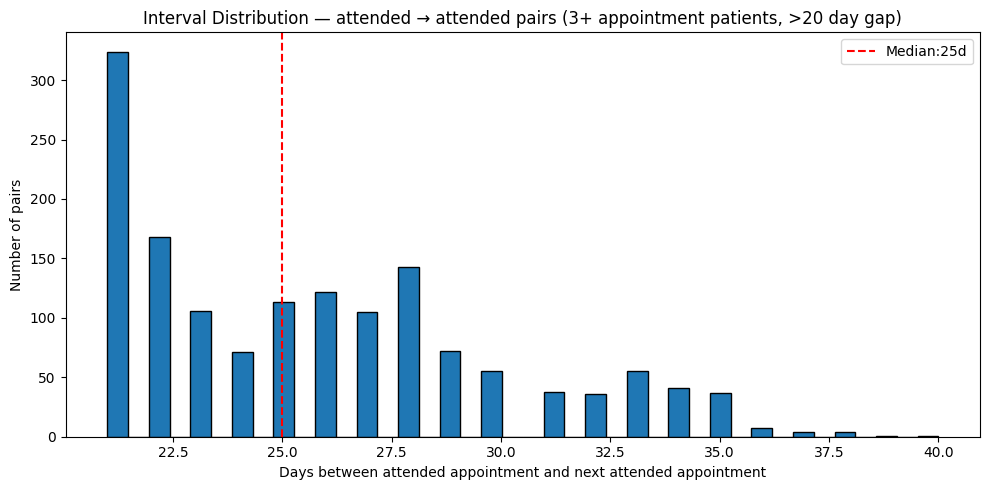

In [15]:
# For patients with 3+ appointments, find consecutive attended → attended pairs with intervals > 20 days, and plot a histogram of those intervals

attr_cols_no_age = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Disability']

three_plus = (
    raw_df.groupby('PatientId')
    .filter(lambda x: len(x) >= 3)
    .sort_values(['PatientId', 'AppointmentDay'])
)

print(f"Patients with 3+ appointments: {three_plus['PatientId'].nunique():,}")

rows = []
for patient_id, grp in three_plus.groupby('PatientId'):
    grp = grp.reset_index(drop=True)
    for i in range(1, len(grp)):
        prev, curr = grp.iloc[i - 1], grp.iloc[i]
        if prev['NoShow'] == 'No' and curr['NoShow'] == 'No':
            elapsed = (curr['AppointmentDay'] - prev['AppointmentDay']).days
            if elapsed > 20:
                diffs = {c: curr[c] - prev[c] for c in attr_cols_no_age}
                rows.append({
                    'PatientId':    patient_id,
                    'noshow_appt':  prev['AppointmentDay'],
                    'show_appt':    curr['AppointmentDay'],
                    'elapsed_days': elapsed,
                    'any_change':   any(d != 0 for d in diffs.values()),
                    **{f'diff_{c}': diffs[c] for c in attr_cols_no_age},
                })

pairs_df = pd.DataFrame(rows)
if pairs_df.empty:
      print("No pairs found matching criteria.")
else:
    total = len(pairs_df)
    changed = pairs_df['any_change'].sum()

    print(f"\nattended → attended pairs with interval > 20 days: {total:,}")
    print(f"With at least one non-Age attribute change:        {changed:,} ({changed/total:.1%})")
    print(f"Identical attributes:                              {total - changed:,} ({(total-changed)/total:.1%})")

    # Interval buckets
    max_days = pairs_df['elapsed_days'].max()
    print(f"Max elapsed days: {max_days}")

    bins = sorted(set([30, 60, 90, 120, 180, 365, max_days + 1]))
    labels = [f"{bins[i]+1}–{bins[i+1]}d" for i in range(len(bins) - 1)]

    pairs_df['interval_bucket'] = pd.cut(pairs_df['elapsed_days'], bins=bins, labels=labels, right=True)
    bucket_summary = pairs_df.groupby('interval_bucket', observed=True).agg(
        pairs=('elapsed_days', 'count'),
        attr_changes=('any_change', 'sum')
    ).assign(pct_changed=lambda x: (x['attr_changes'] / x['pairs'] * 100).round(1))
    print()
    print(bucket_summary)

    # Histogram of intervals
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(pairs_df['elapsed_days'], bins=40, edgecolor='black')
    ax.set_xlabel("Days between attended appointment and next attended appointment")
    ax.set_ylabel("Number of pairs")
    ax.set_title("Interval Distribution — attended → attended pairs (3+ appointment patients, >20 day gap)")
    ax.axvline(pairs_df['elapsed_days'].median(), color='red', linestyle='--', label=f"Median:{pairs_df['elapsed_days'].median():.0f}d")
    ax.legend()
    plt.tight_layout()
    plt.show()

Even though we have way more pairs to work with in this case, the pattern of identical attributes continues...

## Star Schema vs OBT Conclusion

Given that this dataset ultimately only represents a 7-month window and that the data shows that the attributes (save for Age) don't change between appointments irrespective of attendence or interval is an argument for "OBT for now, but star schema if we're being honest about long-term real-world production circumstances". If there was a true separate data source upstream that was capturing and recording changes in patient records outside of this appointment data, this question would be moot -- we absolutely should have a SCD2 table to show those patient records's history and how they change over time with a surrogate key to join onto this appointment data. But if we're just working with this appointment data, the attributes are arriving embedded in there already so we'd be building a dim table to normalize something that's already event-scoped. 

## ScheduledDay and AppointmentDay (Lead-Time)

Total rows:              110,527
Negative lead time:      38,568 (34.89%)  ← ScheduledDay after AppointmentDay
Zero lead time:          0 (0.00%)
Positive lead time:      71,959 (65.11%)

count    110527.00
mean        233.14
std         365.86
min        -157.82
25%          -8.31
50%          83.37
75%         343.69
max        4285.32
Name: appointment_lead_time_ts, dtype: float64


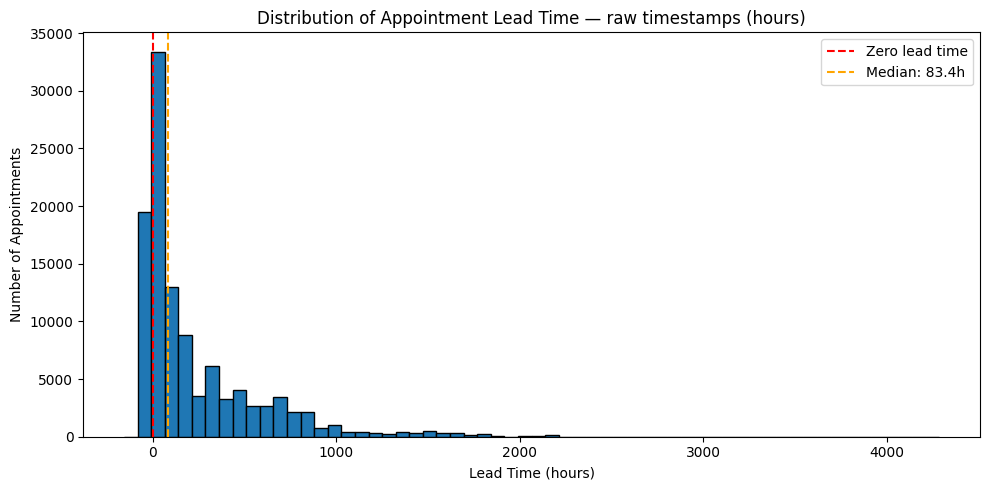

In [16]:
# Add appointment_lead_time using raw timestamps
# We saw in the descriptive stats section evidence of timestamps for ApppointmentDay that were set to midnight
# So we should analyze this in an hour-format first
raw_df['appointment_lead_time_ts'] = (
    raw_df['AppointmentDay'] - raw_df['ScheduledDay']
).dt.total_seconds() / 3600  # in hours for more granularity

negative_ts = (raw_df['appointment_lead_time_ts'] < 0).sum()
zero_ts = (raw_df['appointment_lead_time_ts'] == 0).sum()
positive_ts = (raw_df['appointment_lead_time_ts'] > 0).sum()

print(f"Total rows:              {len(raw_df):,}")
print(f"Negative lead time:      {negative_ts:,} ({negative_ts/len(raw_df):.2%})  ← ScheduledDay after AppointmentDay")
print(f"Zero lead time:          {zero_ts:,} ({zero_ts/len(raw_df):.2%})")
print(f"Positive lead time:      {positive_ts:,} ({positive_ts/len(raw_df):.2%})")
print()
print(raw_df['appointment_lead_time_ts'].describe().round(2))

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(raw_df['appointment_lead_time_ts'], bins=60, edgecolor='black')
ax.set_xlabel("Lead Time (hours)")
ax.set_ylabel("Number of Appointments")
ax.set_title("Distribution of Appointment Lead Time — raw timestamps (hours)")
ax.axvline(0, color='red', linestyle='--', label='Zero lead time')
ax.axvline(raw_df['appointment_lead_time_ts'].median(), color='orange', linestyle='--',
            label=f"Median: {raw_df['appointment_lead_time_ts'].median():.1f}h")
ax.legend()
plt.tight_layout()
plt.show()

Just over a 1/3 of appointments have a negative lead time which is pretty significant. Even though it seems a large majority of them look to fall between 0 and -24 (which would be same-day) looking at the quartiles, it's a bit hard to tell what the distribution of the negative lead time appointments looks like based on the histogram above so let's focus just on those in the next cells below.

In [17]:
neg_mask = raw_df['appointment_lead_time_ts'] < 0
neg_df = raw_df[neg_mask].copy()

neg_df['appt_date']  = neg_df['AppointmentDay'].dt.normalize()
neg_df['sched_date'] = neg_df['ScheduledDay'].dt.normalize()

# Midnight artifact: same calendar day, but AppointmentDay midnight < ScheduledDay's real time
midnight_artifact = neg_df['appt_date'] == neg_df['sched_date']

# Genuinely negative: appointment date is actually before the scheduling date
truly_negative     = neg_df['appt_date'] < neg_df['sched_date']

print(f"Total negative lead time rows:          {len(neg_df):,}")
print(f"  Midnight artifact (same calendar day): {midnight_artifact.sum():,}  ({midnight_artifact.sum()/len(neg_df):.1%})")
print(f"  Genuinely negative (appt date < sched):{truly_negative.sum():,}  ({truly_negative.sum()/len(neg_df):.1%})")

Total negative lead time rows:          38,568
  Midnight artifact (same calendar day): 38,563  (100.0%)
  Genuinely negative (appt date < sched):5  (0.0%)


Only 5 appointments are truly negative in the sense that they were scheduled >= 1 day after the appointment. Let's verify that the vast majority are in fact timestamped to midnight and spot check the 5 genuinely negative appointments to see what other patterns it may betray.

In [18]:
midnight_mask  = neg_df['appt_date'] == neg_df['sched_date']
truly_neg_mask = neg_df['appt_date'] < neg_df['sched_date']
midnight_df  = neg_df[midnight_mask]
at_midnight  = (midnight_df['AppointmentDay'].dt.time == pd.Timestamp('00:00:00').time()).sum()
not_midnight = midnight_mask.sum() - at_midnight

print("=== 1) Midnight artifact verification ===")
print(f"Same-day negative lead time rows:      {midnight_mask.sum():,}")
print(f"  AppointmentDay exactly at midnight:  {at_midnight:,}  ({at_midnight/midnight_mask.sum():.2%})")
print(f"  AppointmentDay NOT at midnight:      {not_midnight:,}  ({not_midnight/midnight_mask.sum():.2%})")

if not_midnight > 0:
    non_mid = midnight_df[midnight_df['AppointmentDay'].dt.time != pd.Timestamp('00:00:00').time()]
    print("\nSame-day negatives where AppointmentDay is NOT midnight:")
    print(non_mid[['AppointmentID', 'ScheduledDay', 'AppointmentDay', 'appointment_lead_time_ts']].to_string(index=False))

=== 1) Midnight artifact verification ===
Same-day negative lead time rows:      38,563
  AppointmentDay exactly at midnight:  38,563  (100.00%)
  AppointmentDay NOT at midnight:      0  (0.00%)


So *all* of the negative lead time appointments are timestamped to midnight for the appointment day. The scale and uniformity here suggests that it's likely something more by design and could indicate a genuine real-world pattern where, for example, clients schedule an appointment then come in the same day. It's also possible that these could be drop-in appointments.

In [19]:
print("\n=== 2) Genuinely negative appointments (appt date < sched date) ===")
cols = ['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'appointment_lead_time_ts', 'Clinic', 'NoShow', 'SMSReminder']
print(neg_df[truly_neg_mask][cols].sort_values('appointment_lead_time_ts').to_string(index=False))


=== 2) Genuinely negative appointments (appt date < sched date) ===
 AppointmentID    PatientId              ScheduledDay            AppointmentDay  appointment_lead_time_ts              Clinic NoShow  SMSReminder
       5686628 9.982316e+14 2016-05-11 13:49:20+00:00 2016-05-05 00:00:00+00:00               -157.822222       Oakmont Ridge    Yes            0
       5715660 7.896294e+12 2016-05-18 14:50:41+00:00 2016-05-17 00:00:00+00:00                -38.844722       Oakmont Ridge    Yes            0
       5664962 2.425226e+13 2016-05-05 13:43:58+00:00 2016-05-04 00:00:00+00:00                -37.732778       Glendale Park    Yes            0
       5679978 7.839273e+12 2016-05-10 10:51:53+00:00 2016-05-09 00:00:00+00:00                -34.864722          Cedar Park    Yes            0
       5655637 3.787482e+12 2016-05-04 06:50:57+00:00 2016-05-03 00:00:00+00:00                -30.849167 Bridgeport Crossing    Yes            0


It's perhaps no surprise that these are all no-shows with SMS reminders in this case. But let's check for the rest of the appointments what the no-show distribution looks like and compare it to the overall no-show rate.

In [20]:
# No-show counts + rate vs. overall
overall_noshow_rate = (raw_df['NoShow'] == 'Yes').mean() * 100
neg_noshow_rate     = (neg_df['NoShow']  == 'Yes').mean() * 100
noshow_counts       = neg_df['NoShow'].value_counts()

print("=== No-show breakdown (negative lead time) ===")
print(neg_df['NoShow'].value_counts().to_frame('Count')
    .assign(Pct=lambda x: (x['Count'] / len(neg_df) * 100).round(1)))
print(f"\nNo-show rate (negative lead time): {neg_noshow_rate:.1f}%")
print(f"No-show rate (overall):            {overall_noshow_rate:.1f}%")


=== No-show breakdown (negative lead time) ===
        Count   Pct
NoShow             
No      36771  95.3
Yes      1797   4.7

No-show rate (negative lead time): 4.7%
No-show rate (overall):            20.2%


That's interesting that the no-show rate is _lower_ for appointments with negative lead times. This actually helps reinforce the idea that these are same-day or drop-in appointments. Given the presumed urgency behind a medical matter that would necessitate a same-day appointment. Or perhaps the fact that these patients are actually physically waiting at a clinic location for a drop-in appointment makes them more invested and therefore less likely to forget.

Something else that we should expect if these are same-day/drop-in appointments is a lack of SMS reminders so let's also take a look at the distribution here for these same negative lead time appointments.

In [21]:
# By SMS reminder
print("\n=== No-show rate by SMS Reminder (negative lead time rows) ===")
print(pd.crosstab(
    neg_df['SMSReminder'],
    neg_df['NoShow'],
    margins=True,
    normalize='index'
).mul(100).round(1).rename(columns={'No': 'Showed (%)', 'Yes': 'No-show (%)'}).rename(index={0: 'No SMS', 1: 'SMS sent', 'All': 'Total'}))


=== No-show rate by SMS Reminder (negative lead time rows) ===
NoShow       Showed (%)  No-show (%)
SMSReminder                         
No SMS             95.3          4.7
Total              95.3          4.7


AHA! There's actually *zero* SMS reminders sent to these patients with appointments that have negative lead times which doubly reinforces our theory that these are legit apppointments likely acutally occurring on the same-day and/or in the form of a drop-in appointment. 

While they have negative lead-times, they shouldn't be excluded from any production dataset but rather flagged as such so that they can be carefully considered based on the analysis (i.e. if we're looking appointments by lead-time, we want a flag to include/exclude them based on whether we want to analyze positive or negative lead-times). 

The exception would be for those 5 truly negative lead-time appointments since they actually present a physical impossibility and should probably warrant an additional flag by way of soft deletion

## Age

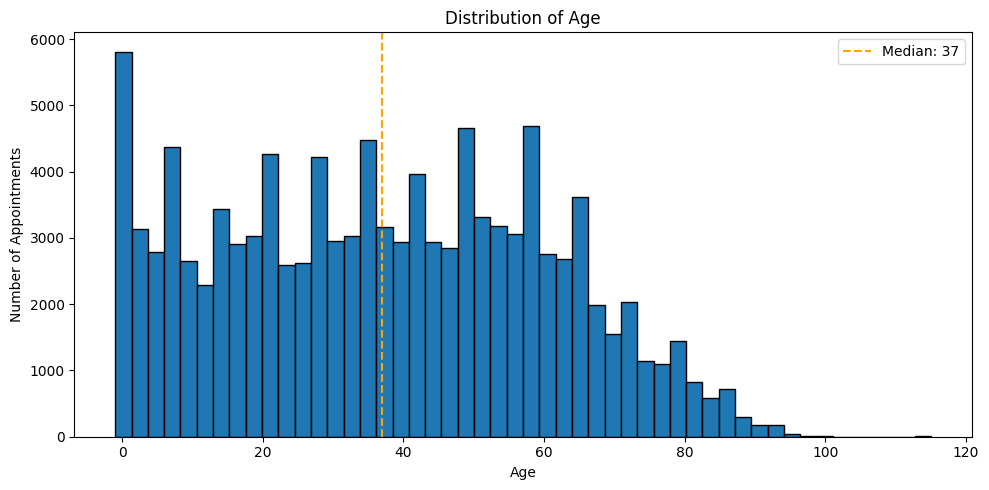

In [22]:
# Histogram of Age
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(raw_df['Age'], bins=50, edgecolor='black')
ax.set_xlabel("Age")
ax.set_ylabel("Number of Appointments")
ax.set_title("Distribution of Age")
ax.axvline(raw_df['Age'].median(), color='orange', linestyle='--',
            label=f"Median: {raw_df['Age'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

Looks like a fairly normal age distribution for a patient group. But we saw earlier int he descriptive stats section that there was at least one person with Age = -1. So let's check all the out-of-bound ages 

In [23]:
# Out-of-range rows
print("=== Rows with Age < 0 ===")
pd.set_option('display.max_columns', None)
print(raw_df[raw_df['Age'] < 0].to_string(index=False))

print("\n=== Rows with Age > 100 ===")
print(raw_df[raw_df['Age'] > 100].to_string(index=False))

=== Rows with Age < 0 ===
   PatientId  AppointmentID Gender              ScheduledDay            AppointmentDay  Age            Clinic  LowIncome  Hypertension  Diabetes  SubstanceUseDisorder  Disability  SMSReminder NoShow  appointment_lead_time_ts
4.659432e+14        5775010      F 2016-06-06 08:58:13+00:00 2016-06-06 00:00:00+00:00   -1 Stonegate Commons          0             0         0                     0           0            0     No                 -8.970278

=== Rows with Age > 100 ===
   PatientId  AppointmentID Gender              ScheduledDay            AppointmentDay  Age              Clinic  LowIncome  Hypertension  Diabetes  SubstanceUseDisorder  Disability  SMSReminder NoShow  appointment_lead_time_ts
9.762948e+14        5651757      F 2016-05-03 09:14:53+00:00 2016-05-03 00:00:00+00:00  102   Crestmont Heights          0             0         0                     0           0            0     No                 -9.248056
3.196321e+13        5700278      F 2016-0

The person with Age = -1 is very likely an error unless it's their way of designating that this was a fetal check-up appointment or something similar. But in these cases, it's more likely that the patient would be the mother...

The people above age 100 don't especially seem suspicious though it's extremely rare to have people above the age of 110 in any given population. The number 5 seems to keep coming up a lot in the course of our analyses here when it comes to errant data so the fact that there's 5 individuals aged 115 does seem to a little coincidental but there's nothing to suggest that the data is incorrect.

In [24]:
# Age == 0 count
age_zero_patients = raw_df[raw_df['Age'] == 0]['PatientId'].nunique()
total_patients = raw_df['PatientId'].nunique()
print(f"Patients with Age = 0: {age_zero_patients:,} ({age_zero_patients/total_patients:.2%})")

Patients with Age = 0: 2,082 (3.34%)


Since there's a decent number of patients with Age = 0, I'm presuming that these are in fact newborns. 

However, let's check the other column values for some of these just to be sure that there's nothing suspiciously out of place.

It would be highly unusual if we saw that there were a large proportion of these newborn patients with Diabetes for example.

In [25]:
age_zero_ids = raw_df[raw_df['Age'] == 0]['PatientId'].unique()
age_zero_df  = raw_df[raw_df['PatientId'].isin(age_zero_ids)].copy()

print(f"Patients with Age = 0: {len(age_zero_ids):,}")
print(f"Total appointments for these patients: {len(age_zero_df):,}\n")

attr_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Disability']

# Flag rate for each attribute vs. rest of dataset
rest_df = raw_df[~raw_df['PatientId'].isin(age_zero_ids)]

comparison = pd.DataFrame({
    'Age=0 patients (%)': age_zero_df[attr_cols].mean().mul(100).round(1),
    'All others (%)':     rest_df[attr_cols].mean().mul(100).round(1),
})
comparison['Diff (pp)'] = (comparison['Age=0 patients (%)'] - comparison['All others (%)']).round(1)
print("=== Attribute flag rates ===")
print(comparison)

Patients with Age = 0: 2,082
Total appointments for these patients: 3,621

=== Attribute flag rates ===
                      Age=0 patients (%)  All others (%)  Diff (pp)
LowIncome                            1.4            10.1       -8.7
Hypertension                         0.0            20.4      -20.4
Diabetes                             0.0             7.4       -7.4
SubstanceUseDisorder                 0.0             3.1       -3.1
Disability                           0.0             2.3       -2.3


The comorbidity flags check out but the LowIncome column is a bit odd since it could in one sense refer to the socioecnomic status of a newborn. However, it's possible that this particular column reflects the overall socioeconomic status of the family rather than the individual.

## Clinic

              Clinic  appointments  no_shows  no_show_rate  pct_of_total
   Greenwood Village          7717      1465          19.0           7.0
   Maplewood Heights          5805      1219          21.0           5.3
          Cedar Park          4431       906          20.4           4.0
   Riverside Commons          3877       631          16.3           3.5
    Lakeview Terrace          3514       923          26.3           3.2
    Downtown Central          3334       703          21.1           3.0
 Bridgeport Crossing          3132       573          18.3           2.8
     Hillcrest Plaza          3131       496          15.8           2.8
    Northgate Square          2853       696          24.4           2.6
    Fairview Station          2773       550          19.8           2.5
       Oakmont Ridge          2746       484          17.6           2.5
   Westfield Landing          2571       508          19.8           2.3
  Clearwater Springs          2565       591       

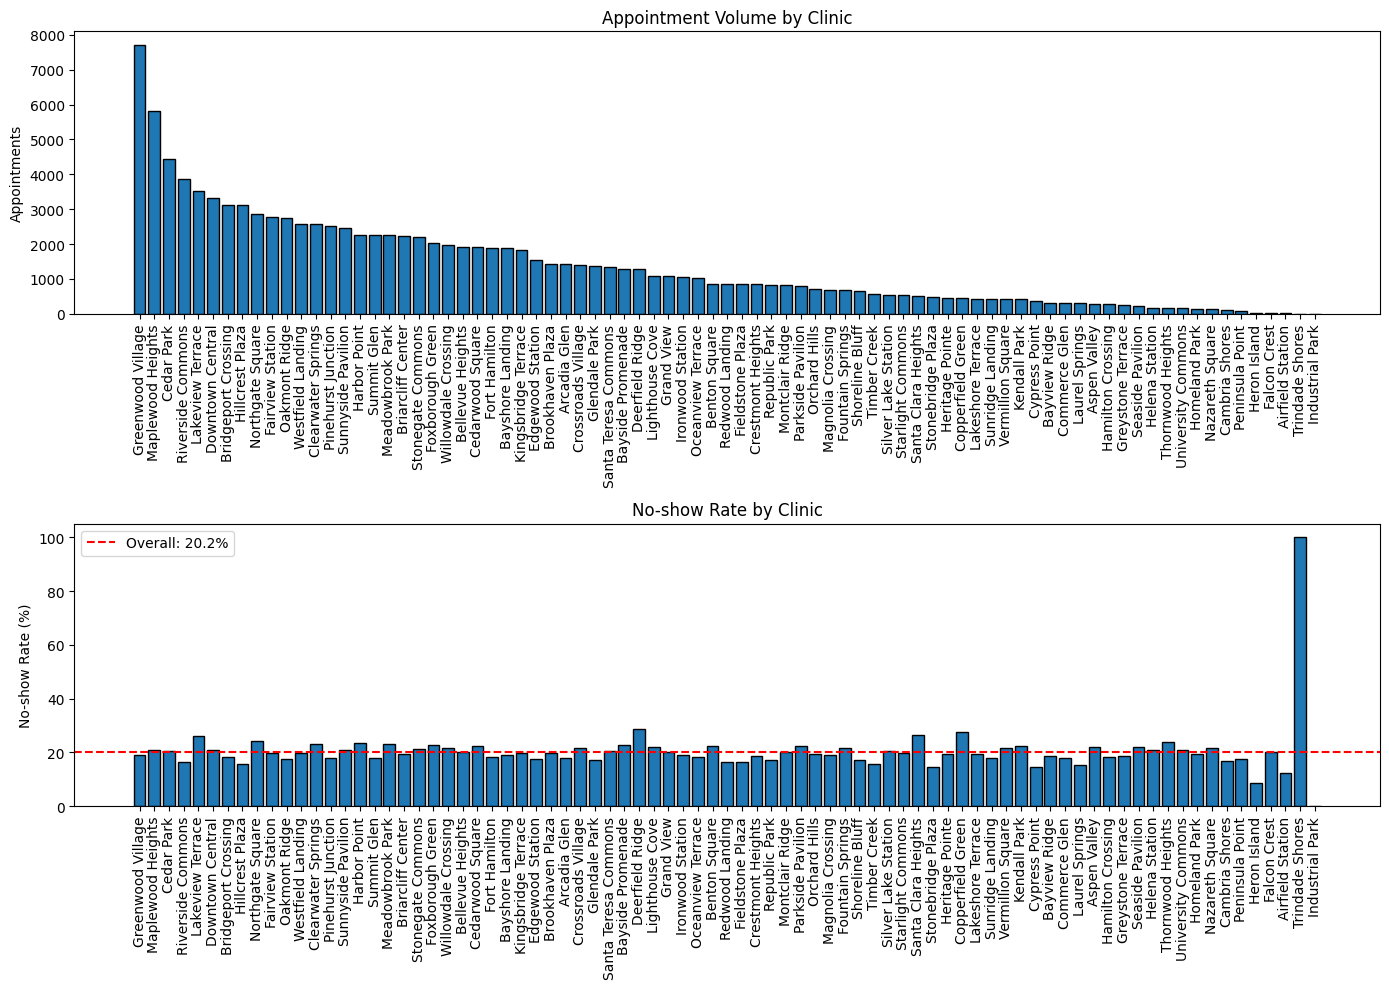

In [26]:
raw_df['no_show'] = (raw_df['NoShow'] == 'Yes').astype(int)
overall_rate = raw_df['no_show'].mean() * 100

clinic_summary = (
    raw_df.groupby('Clinic')
    .agg(appointments=('no_show', 'count'), no_shows=('no_show', 'sum'))
    .assign(
        no_show_rate=lambda x: (x['no_shows'] / x['appointments'] * 100).round(1),
        pct_of_total=lambda x: (x['appointments'] / x['appointments'].sum() * 100).round(1)
    )
    .sort_values('appointments', ascending=False)
    .reset_index()
)
print(clinic_summary.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Volume
ax1.bar(clinic_summary['Clinic'], clinic_summary['appointments'], edgecolor='black')
ax1.set_ylabel("Appointments")
ax1.set_title("Appointment Volume by Clinic")
ax1.tick_params(axis='x', rotation=90)

# No-show rate
ax2.bar(clinic_summary['Clinic'], clinic_summary['no_show_rate'], edgecolor='black')
ax2.axhline(overall_rate, color='red', linestyle='--', label=f"Overall: {overall_rate:.1f}%")
ax2.set_ylabel("No-show Rate (%)")
ax2.set_title("No-show Rate by Clinic")
ax2.tick_params(axis='x', rotation=90)
ax2.legend()

plt.tight_layout()
plt.show()

The volume looks normal as one could expect a sort of power-rule log distribution of appointment volume based on a lot of factors not captured here: clinic size, clinic staff, clinic location, appointment costs, etc.

The no-show rate for the two smallest clinic by appointment volume are 100% and 0% respectively but that's based on sample sizes of 2 and 1 again respectively.

=== Negative Lead Time by Clinic ===
              Clinic  appointments  negative_lt  pct_negative
     Industrial Park             1            1         100.0
       Cypress Point           371          198          53.4
         Summit Glen          2264         1078          47.6
     Hillcrest Plaza          3131         1483          47.4
    Foxborough Green          2018          913          45.2
   Crestmont Heights           849          377          44.4
    Brookhaven Plaza          1439          613          42.6
    Bellevue Heights          1907          794          41.6
       Glendale Park          1376          568          41.3
       Oakmont Ridge          2746         1125          41.0
     Peninsula Point            69           28          40.6
        Arcadia Glen          1427          575          40.3
    Edgewood Station          1553          622          40.1
     Heritage Pointe           452          178          39.4
 Bridgeport Crossing          313

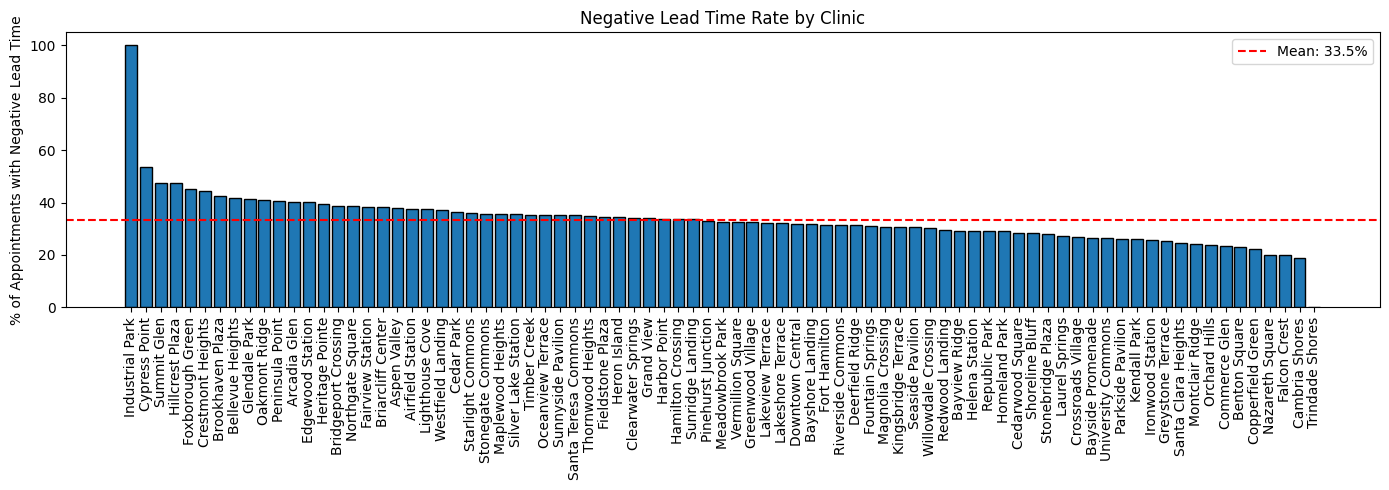

In [27]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

raw_df['appointment_lead_time_ts'] = (
    raw_df['AppointmentDay'] - raw_df['ScheduledDay']
).dt.total_seconds() / 3600

# === Negative lead time by clinic ===
clinic_leadtime = (
    raw_df.groupby('Clinic')
    .agg(
        appointments=('AppointmentID', 'count'),
        negative_lt=('appointment_lead_time_ts', lambda x: (x < 0).sum())
    )
    .assign(pct_negative=lambda x: (x['negative_lt'] / x['appointments'] * 100).round(1))
    .sort_values('pct_negative', ascending=False)
    .reset_index()
)
print("=== Negative Lead Time by Clinic ===")
print(clinic_leadtime.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(clinic_leadtime['Clinic'], clinic_leadtime['pct_negative'], edgecolor='black')
ax.axhline(clinic_leadtime['pct_negative'].mean(), color='red', linestyle='--',
            label=f"Mean: {clinic_leadtime['pct_negative'].mean():.1f}%")
ax.set_ylabel("% of Appointments with Negative Lead Time")
ax.set_title("Negative Lead Time Rate by Clinic")
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

Nothing very unusual here given that we've already identified that Industrial Park and Trindad Shores are very low apppointment volume clinics


=== Comorbidity Flag Rates by Clinic (% of patients) ===
              Clinic  LowIncome  Hypertension  Diabetes  SubstanceUseDisorder
   Greenwood Village        2.1           6.3       3.3                   0.2
   Maplewood Heights        2.1           1.9       0.7                   0.1
          Cedar Park        9.9          18.8       6.2                   1.3
   Riverside Commons        0.3          27.3       8.9                   0.5
    Lakeview Terrace        8.7          21.6       7.4                   2.3
    Downtown Central        3.6          22.8       7.8                   1.1
 Bridgeport Crossing       15.6          23.0       7.2                   2.2
     Hillcrest Plaza       14.0          24.7       9.1                   7.0
    Northgate Square        6.6          17.1       6.3                   3.9
    Fairview Station       13.8          23.2       7.9                   4.0
       Oakmont Ridge        4.7          25.8       8.7                   1.7
   Wes

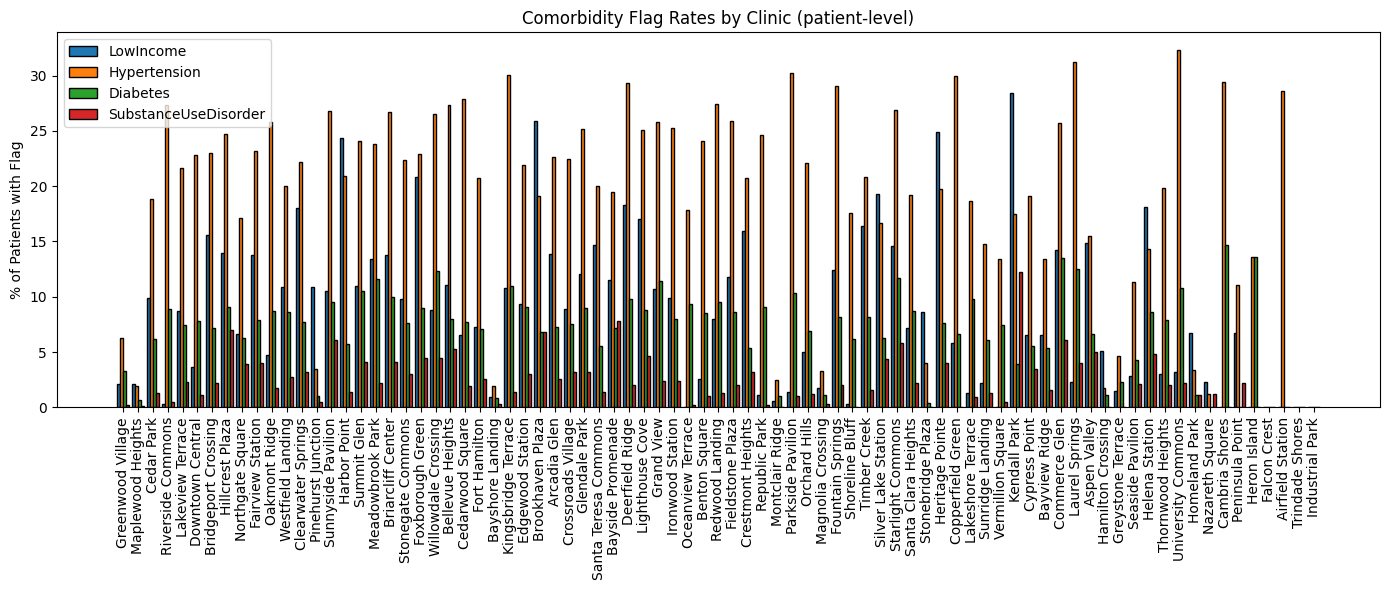

In [28]:

# === Comorbidity flag rates by clinic (patient-level) ===
patient_clinic = raw_df.groupby('PatientId').agg(
    Clinic=('Clinic', 'first'),
    **{flag: (flag, 'first') for flag in flag_cols}
).reset_index()

clinic_order = clinic_summary['Clinic'].tolist()  # already sorted by volume from earlier

clinic_flags = (
    patient_clinic.groupby('Clinic')[flag_cols]
    .mean()
    .mul(100)
    .round(1)
    .reindex(clinic_order)
    .reset_index()
)
print("\n=== Comorbidity Flag Rates by Clinic (% of patients) ===")
print(clinic_flags.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(clinic_flags))
width = 0.2
for i, flag in enumerate(flag_cols):
    ax.bar([xi + i * width for xi in x], clinic_flags[flag], width, label=flag, edgecolor='black')
ax.set_xticks([xi + width * 1.5 for xi in x])
ax.set_xticklabels(clinic_flags['Clinic'], rotation=90)
ax.set_ylabel("% of Patients with Flag")
ax.set_title("Comorbidity Flag Rates by Clinic (patient-level)")
ax.legend()
plt.tight_layout()
plt.show()

There's some larger clinics by appointment volume which have a decently low average patient risk profile like Greenwood Village, Maplewood Heights, Bayshore Landing, Montclair Ridge and Magnolia Crossing. But again, it's likely reflective of many contextual variables not seen or captured here about the clinics.

## Comorbidity Flags (LowIncome, Hypertension, Diabetes, and SubstanceUseDisorder)

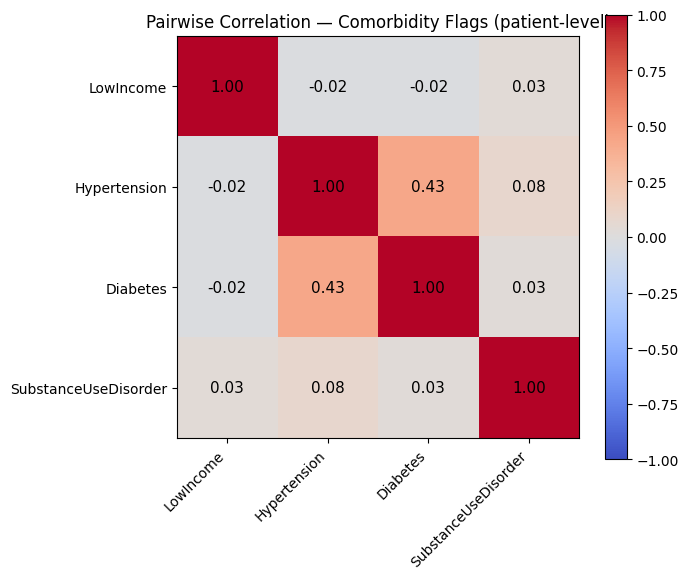

In [29]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

# Patient-level: take the first recorded value per patient for each flag (we saw earlier that these flags don't change in this dataset anyway)
patient_flags = raw_df.groupby('PatientId')[flag_cols].first()

corr = patient_flags.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(flag_cols)))
ax.set_yticks(range(len(flag_cols)))
ax.set_xticklabels(flag_cols, rotation=45, ha='right')
ax.set_yticklabels(flag_cols)

for i in range(len(flag_cols)):
    for j in range(len(flag_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=11)

ax.set_title("Pairwise Correlation — Comorbidity Flags (patient-level)")
plt.tight_layout()
plt.show()

The Diabtetes-Hypertension relationship is not that surprising, but, perhaps somewhat cynically, the correlation between SubstanceUseDisorder and LowIncome is weaker than Hypertension.

However, this may be confounded by the earlier observation that there is at least a small cohort of patients with Age = 0 that have this flag.

In [30]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

patient_flags = raw_df.groupby('PatientId')[flag_cols].first()

flag_summary = pd.DataFrame({
    'Patients with flag': patient_flags[flag_cols].sum().astype(int),
    'Pct of patients':    (patient_flags[flag_cols].mean() * 100).round(1)
}).sort_values('Patients with flag', ascending=False)

print(flag_summary.to_string())

                      Patients with flag  Pct of patients
Hypertension                       12242             19.7
LowIncome                           5788              9.3
Diabetes                            4416              7.1
SubstanceUseDisorder                1506              2.4


Earlier we saw that only about 1.5% percent of the 2,000-odd patients with Age = 0 had the LowIncome flag so it seems mathematically unlikely it had a profound effect on the correlation but still worth noting (since the effect is > 0)

 Flags  Patients  Pct
     0     43767 70.3
     1     13535 21.7
     2      4589  7.4
     3       393  0.6
     4        15  0.0


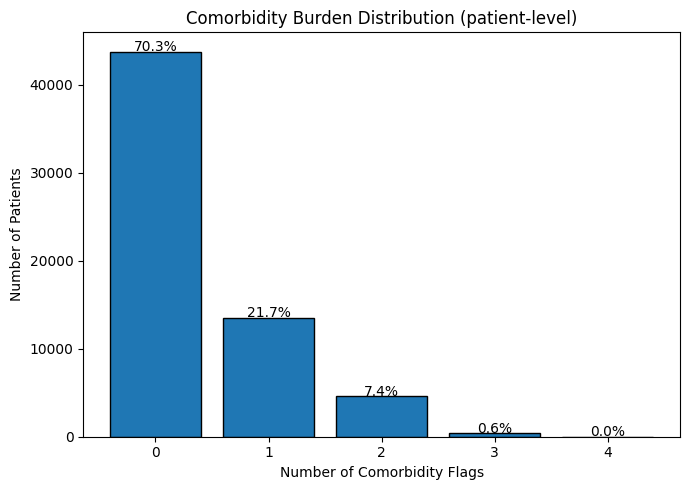

In [31]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

# Patient-level burden score (0–4)
patient_flags = raw_df.groupby('PatientId')[flag_cols].first()
patient_flags['burden'] = patient_flags[flag_cols].sum(axis=1)

burden_summary = (
    patient_flags['burden']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'burden': 'Flags', 'count': 'Patients'})
    .assign(Pct=lambda x: (x['Patients'] / x['Patients'].sum() * 100).round(1))
)
print(burden_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(burden_summary['Flags'], burden_summary['Patients'], edgecolor='black')
ax.set_xlabel("Number of Comorbidity Flags")
ax.set_ylabel("Number of Patients")
ax.set_title("Comorbidity Burden Distribution (patient-level)")
for _, row in burden_summary.iterrows():
    ax.text(row['Flags'], row['Patients'] + 50, f"{row['Pct']}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

It's curious to see this when we factor in that we're told Disability is not a boolean and that its min/max range from 0-4 from the descriptive stats output. Is it possible that Disability refers to these comorbidity flags? It's an easy check to see if Disability at least simply refers to the sum of these flags above.

In [32]:
cols = ['AppointmentID', 'PatientId', 'Age', 'Gender', 'Disability',
          'LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder', 'Clinic', 'NoShow']

pd.set_option('display.max_columns', None)
print(raw_df[raw_df['Disability'] == 2][cols].head(20).to_string(index=False))
print(f"\nTotal rows where Disability = 2: {(raw_df['Disability'] == 2).sum():,}")

 AppointmentID    PatientId  Age Gender  Disability  LowIncome  Hypertension  Diabetes  SubstanceUseDisorder               Clinic NoShow
       5582483 7.282582e+13   94      M           2          0             1         1                     0     Bellevue Heights     No
       5525497 1.242919e+13   64      M           2          0             1         0                     1      Hillcrest Plaza     No
       5525498 1.242919e+13   64      M           2          0             1         0                     1      Hillcrest Plaza     No
       5640120 1.242919e+13   64      M           2          0             1         0                     1      Hillcrest Plaza     No
       5638626 1.491829e+13   11      F           2          0             0         0                     0     Meadowbrook Park     No
       5640766 3.423831e+09   29      F           2          0             0         0                     0      Redwood Landing     No
       5589893 4.415275e+13   17      M  

It doesn't appear that Disability's value refers to the other comorbidity flags as I can see in the small smaple that several patients have Disability = 2 but zeroes across the board for their comorbidity flags

 Flags  appointments  no_shows  no_show_rate
     0         76779     15778          20.5
     1         24420      4790          19.6
     2          8459      1593          18.8
     3           849       151          17.8
     4            20         7          35.0


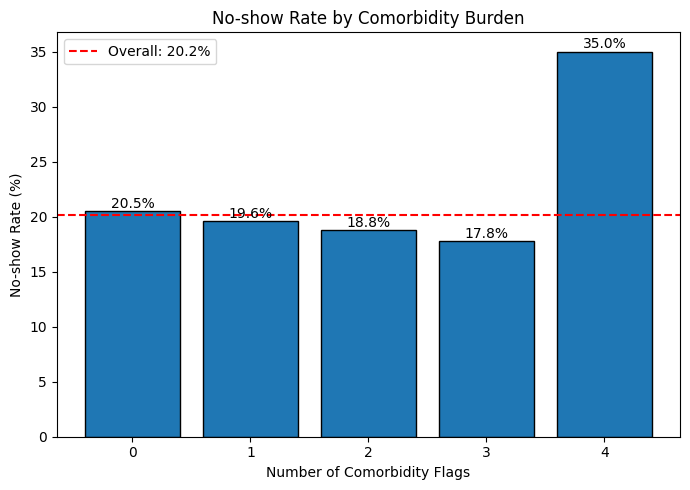

In [33]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

# Patient-level burden
patient_burden = (
    raw_df.groupby('PatientId')[flag_cols].first()
    .sum(axis=1)
    .rename('burden')
    .reset_index()
)

# Appointment-level: join burden back, compute no-show rate
appt_df = raw_df.merge(patient_burden, on='PatientId')
appt_df['no_show'] = (appt_df['NoShow'] == 'Yes').astype(int)

burden_noshow = (
    appt_df.groupby('burden')
    .agg(appointments=('no_show', 'count'), no_shows=('no_show', 'sum'))
    .assign(no_show_rate=lambda x: (x['no_shows'] / x['appointments'] * 100).round(1))
    .reset_index()
    .rename(columns={'burden': 'Flags'})
)
print(burden_noshow.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(burden_noshow['Flags'], burden_noshow['no_show_rate'], edgecolor='black')
ax.set_xlabel("Number of Comorbidity Flags")
ax.set_ylabel("No-show Rate (%)")
ax.set_title("No-show Rate by Comorbidity Burden")
ax.axhline(appt_df['no_show'].mean() * 100, color='red', linestyle='--',
            label=f"Overall: {appt_df['no_show'].mean()*100:.1f}%")
for _, row in burden_noshow.iterrows():
    ax.text(row['Flags'], row['no_show_rate'] + 0.3, f"{row['no_show_rate']}%", ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

This is very interesting as it shows that we actually have a slightly decreasing no-show rate until we hit those patients with all 4 flags.

However, it's worth bearing in mind that this is ultimately based on a small sample of about 15 patients.

I'm curious to know now if there's a single comorbidity condition that is associated with a higher no-show rate?

Overall no-show rate: 20.2%

                Flag  With flag (%)  Without flag (%)  Diff (pp)  N (with flag)
           LowIncome           23.7              19.8        3.9          10861
SubstanceUseDisorder           20.1              20.2       -0.0           3360
            Diabetes           18.0              20.4       -2.4           7943
        Hypertension           17.3              20.9       -3.6          21801


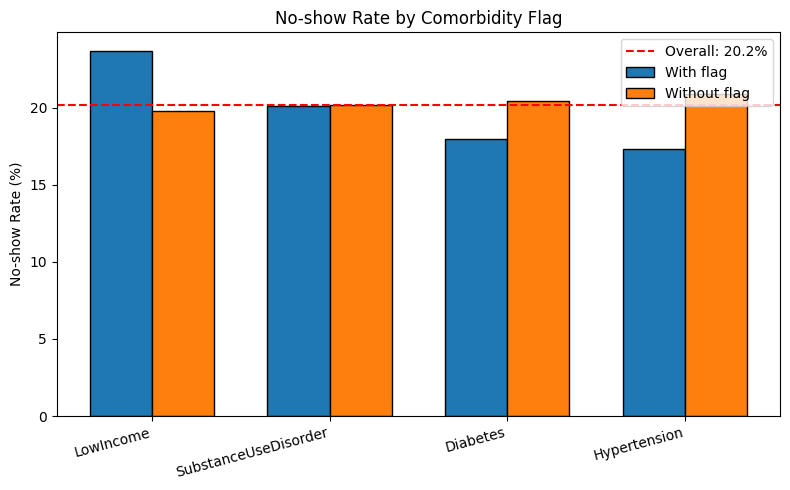

In [34]:
flag_cols = ['LowIncome', 'Hypertension', 'Diabetes', 'SubstanceUseDisorder']

raw_df['no_show'] = (raw_df['NoShow'] == 'Yes').astype(int)
overall_rate = raw_df['no_show'].mean() * 100

rows = []
for flag in flag_cols:
    with_flag    = raw_df[raw_df[flag] == 1]['no_show']
    without_flag = raw_df[raw_df[flag] == 0]['no_show']
    rows.append({
        'Flag':              flag,
        'With flag (%)':     round(with_flag.mean() * 100, 1),
        'Without flag (%)':  round(without_flag.mean() * 100, 1),
        'Diff (pp)':         round((with_flag.mean() - without_flag.mean()) * 100, 1),
        'N (with flag)':     len(with_flag),
    })

result = pd.DataFrame(rows).sort_values('Diff (pp)', ascending=False)
print(f"Overall no-show rate: {overall_rate:.1f}%\n")
print(result.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(flag_cols))
width = 0.35
sorted_flags = result['Flag'].tolist()
ax.bar([i - width/2 for i in x], result['With flag (%)'],    width, label='With flag',    edgecolor='black')
ax.bar([i + width/2 for i in x], result['Without flag (%)'], width, label='Without flag', edgecolor='black')
ax.axhline(overall_rate, color='red', linestyle='--', label=f"Overall: {overall_rate:.1f}%")
ax.set_xticks(list(x))
ax.set_xticklabels(sorted_flags, rotation=15, ha='right')
ax.set_ylabel("No-show Rate (%)")
ax.set_title("No-show Rate by Comorbidity Flag")
ax.legend()
plt.tight_layout()
plt.show()

Hmmm so it appears that the presence of the LowIncome flag does indicate a higher-chance of a no-show appointment.

I think this has a real-world basis in the sense that clinic appointments are often either expensive by themselves (paying to see a specialist for example) or results in expensive treatment (having to pay for a procedure or medication). Both of which add financial strain so it's likely LowIncome patients will weigh attendence differently.

Just to close the loop here, I am curious about what this flag portends for those patients with Age = 0 we saw earlier and if their attendence rate varies greatly from the overall ~20% average.

In [35]:
age_zero_lowincome = raw_df[(raw_df['Age'] == 0) & (raw_df['LowIncome'] == 1)]

total = len(age_zero_lowincome)
noshow_counts = age_zero_lowincome['NoShow'].value_counts()
noshow_rate = (age_zero_lowincome['NoShow'] == 'Yes').mean() * 100

print(f"Appointments (Age=0, LowIncome=1): {total:,}")
print(f"\n{noshow_counts.to_frame('Count').assign(Pct=lambda x: (x['Count']/total*100).round(1))}")
print(f"\nNo-show rate: {noshow_rate:.1f}%")
print(f"Overall rate: {(raw_df['NoShow'] == 'Yes').mean()*100:.1f}%")

Appointments (Age=0, LowIncome=1): 52

        Count   Pct
NoShow             
No         45  86.5
Yes         7  13.5

No-show rate: 13.5%
Overall rate: 20.2%


This is also interesting as it potentially suggests that the parents are less inclined to no-show for an appointment if it concerns their newborn 

## Disability

 Disability Value  Patients  Pct
                0     61166 98.2
                1      1025  1.6
                2        99  0.2
                3         6  0.0
                4         3  0.0


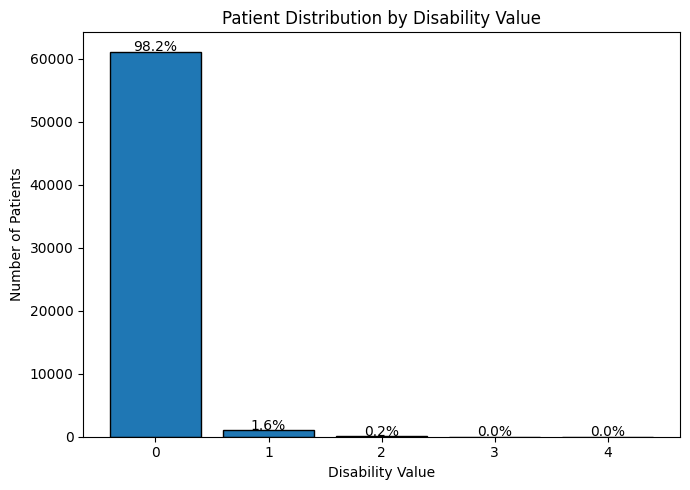

In [36]:
patient_disability = raw_df.groupby('PatientId')['Disability'].first()

disability_summary = (
    patient_disability.value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Disability': 'Disability Value', 'count': 'Patients'})
    .assign(Pct=lambda x: (x['Patients'] / x['Patients'].sum() * 100).round(1))
)
print(disability_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(disability_summary['Disability Value'], disability_summary['Patients'], edgecolor='black')
ax.set_xlabel("Disability Value")
ax.set_ylabel("Number of Patients")
ax.set_title("Patient Distribution by Disability Value")
for _, row in disability_summary.iterrows():
    ax.text(row['Disability Value'], row['Patients'] + 50, f"{row['Pct']}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Since Disability is not a boolean flag column like the other comorbidity conditions, we're left with 2 possibilities: either it's encoding for a specific disability (0 meaning healthy, 1 meaning leg paralysis, 2 meaning visual impairment, etc) or it's encoding for severity (0 meaning healthy, 1 meaning slightly impaired, 2 meaning moderately impaired, etc).

Based on the distribution of the values and the patient count drop-off in higher values, it would make more sense if Disability encoded for the latter.

Out of curiousity, I wonder if patients with disability tend to also have higher levels of comorbidity conditions (excepting maybe LowIncome SUbstanceUseDisorder). My reasoning here is this: if you're disabled, your lifestyle might be more sedentary and therefore you may be more predisposed to develop Diabetes and/or Hypertension.

 Disability  Hypertension  Diabetes
          0          19.1       6.9
          1          47.9      19.4
          2          37.4      17.2
          3          16.7       0.0
          4           0.0       0.0


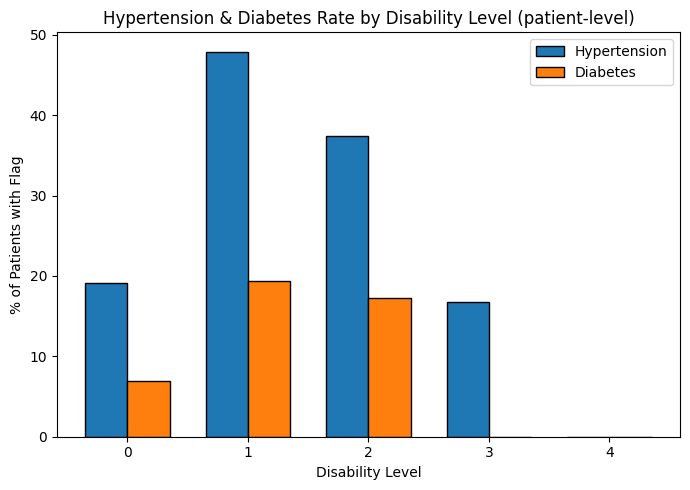

In [37]:
flag_cols = ['Hypertension', 'Diabetes']

patient_attrs = raw_df.groupby('PatientId')[['Disability'] + flag_cols].first().reset_index()

by_level = (
    patient_attrs.groupby('Disability')[flag_cols]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)
print(by_level.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(by_level))
width = 0.35
ax.bar([i - width/2 for i in x], by_level['Hypertension'], width, label='Hypertension', edgecolor='black')
ax.bar([i + width/2 for i in x], by_level['Diabetes'],     width, label='Diabetes',     edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(by_level['Disability'].astype(int))
ax.set_xlabel("Disability Level")
ax.set_ylabel("% of Patients with Flag")
ax.set_title("Hypertension & Diabetes Rate by Disability Level (patient-level)")
ax.legend()
plt.tight_layout()
plt.show()

Though the sample sizes here may be very small (~2% of all patients have Disability > 0 with near negligible patient numbers for Disability 3 and 4), I'm inclined to believe that Disability is encoding for severity. 

While these results are still possible if Disability happened to be encoding for specific impairments that also correlate well with these comorbidity conditions, I'm still in favor of severity due to Occam's Razor.

Also, I believe there's perhaps a real-world explanation for why Disability = 1 shows higher levels of comorbidity rates than Disability = 2 beyond mere sampling error: those that are more disabled tend to actually have more experience and/or help managing their impairments than those who are more minorly impaired. The greatest drop-off in quality of life and coping mechanisms is between Disability = 0 and Disability = 1 purely in terms of its pscyhological impact.

## SMS Reminder

     SMS  appointments  no_shows  no_show_rate  pct_of_total
  No SMS         75045     12535          16.7          67.9
SMS sent         35482      9784          27.6          32.1


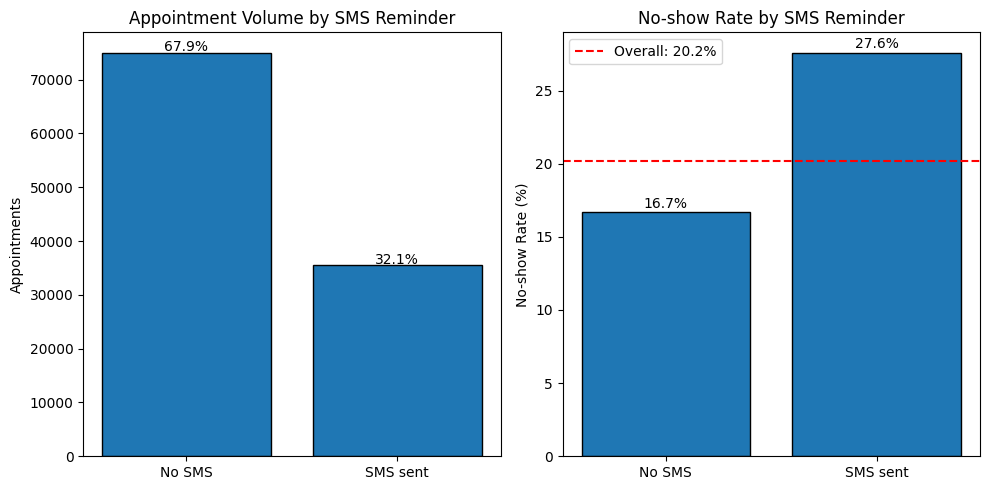

In [38]:
raw_df['no_show'] = (raw_df['NoShow'] == 'Yes').astype(int)
overall_rate = raw_df['no_show'].mean() * 100

sms_summary = (
    raw_df.groupby('SMSReminder')
    .agg(appointments=('no_show', 'count'), no_shows=('no_show', 'sum'))
    .assign(
        no_show_rate=lambda x: (x['no_shows'] / x['appointments'] * 100).round(1),
        pct_of_total=lambda x: (x['appointments'] / x['appointments'].sum() * 100).round(1)
    )
    .rename(index={0: 'No SMS', 1: 'SMS sent'})
    .reset_index()
    .rename(columns={'SMSReminder': 'SMS'})
)
print(sms_summary.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(sms_summary['SMS'], sms_summary['appointments'], edgecolor='black')
ax1.set_ylabel("Appointments")
ax1.set_title("Appointment Volume by SMS Reminder")
for _, row in sms_summary.iterrows():
    ax1.text(row['SMS'], row['appointments'] + 200, f"{row['pct_of_total']}%", ha='center', fontsize=10)

ax2.bar(sms_summary['SMS'], sms_summary['no_show_rate'], edgecolor='black')
ax2.axhline(overall_rate, color='red', linestyle='--', label=f"Overall: {overall_rate:.1f}%")
ax2.set_ylabel("No-show Rate (%)")
ax2.set_title("No-show Rate by SMS Reminder")
for _, row in sms_summary.iterrows():
    ax2.text(row['SMS'], row['no_show_rate'] + 0.3, f"{row['no_show_rate']}%", ha='center', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()

Oddly enough, SMS seems to actually _increase_ the no-show rate for appointments. However, it's very possible here that SMS is sent to a group already pre-disposed to forget or avoid their scheduled appointments.

Since we saw earlier that same-day/drop-in appointments don't have any SMSReminder flags = 1, let's focus on the positive lead time appointments and map out what the no-show rates for different buckets of these lead times look like with and without SMS reminders.

lead_bucket      SMS  appointments  no_shows  no_show_rate
       1–3d   No SMS          8556      2053          24.0
       1–3d SMS sent           906       193          21.3
       3–7d   No SMS          6868      1862          27.1
       3–7d SMS sent         10642      2551          24.0
      7–14d   No SMS          5021      1695          33.8
      7–14d SMS sent          7004      1969          28.1
     14–30d   No SMS          6851      2526          36.9
     14–30d SMS sent         10520      3135          29.8
     30–60d   No SMS          3224      1237          38.4
     30–60d SMS sent          5059      1592          31.5
     60–90d   No SMS           666       233          35.0
     60–90d SMS sent          1212       307          25.3
       90d+   No SMS            78        19          24.4
       90d+ SMS sent           139        37          26.6


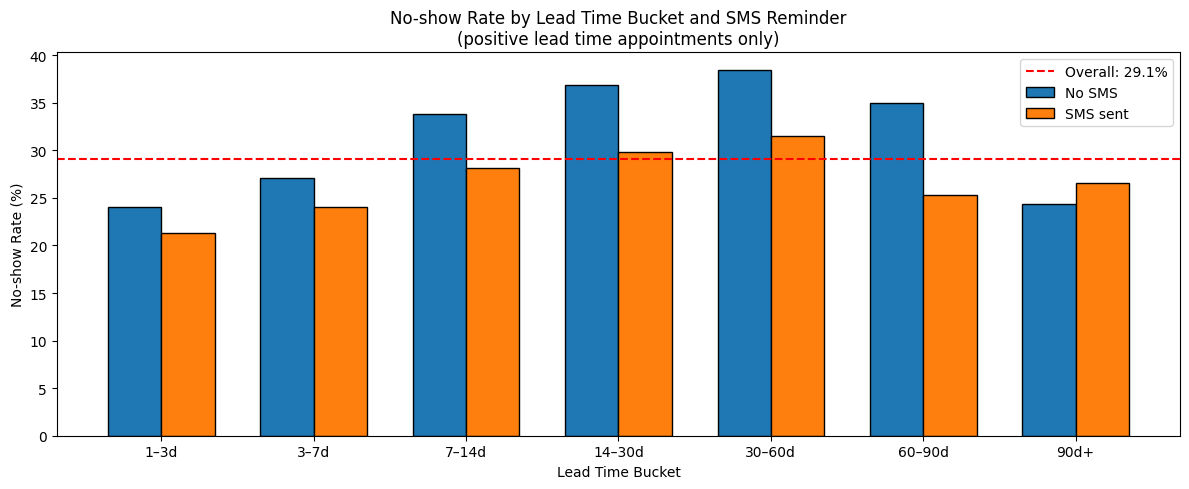

In [39]:
raw_df['no_show'] = (raw_df['NoShow'] == 'Yes').astype(int)
raw_df['appointment_lead_time_ts'] = (
    raw_df['AppointmentDay'] - raw_df['ScheduledDay']
).dt.total_seconds() / 3600

pos_df = raw_df[raw_df['appointment_lead_time_ts'] > 24].copy()
pos_df['lead_time_days'] = pos_df['appointment_lead_time_ts'] / 24

bins   = [1, 3, 7, 14, 30, 60, 90, float('inf')]
labels = ['1–3d', '3–7d', '7–14d', '14–30d', '30–60d', '60–90d', '90d+']
pos_df['lead_bucket'] = pd.cut(pos_df['lead_time_days'], bins=bins, labels=labels)

bucket_sms = (
    pos_df.groupby(['lead_bucket', 'SMSReminder'], observed=True)
    .agg(appointments=('no_show', 'count'), no_shows=('no_show', 'sum'))
    .assign(no_show_rate=lambda x: (x['no_shows'] / x['appointments'] * 100).round(1))
    .reset_index()
)

no_sms = bucket_sms[bucket_sms['SMSReminder'] == 0].set_index('lead_bucket')
sms    = bucket_sms[bucket_sms['SMSReminder'] == 1].set_index('lead_bucket')

print(bucket_sms.rename(columns={'SMSReminder': 'SMS'})
    .assign(SMS=lambda x: x['SMS'].map({0: 'No SMS', 1: 'SMS sent'}))
    .to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels))
width = 0.35
ax.bar([i - width/2 for i in x], no_sms.reindex(labels)['no_show_rate'], width, label='No SMS',   edgecolor='black')
ax.bar([i + width/2 for i in x], sms.reindex(labels)['no_show_rate'],    width, label='SMS sent', edgecolor='black')
ax.axhline(pos_df['no_show'].mean() * 100, color='red', linestyle='--',
            label=f"Overall: {pos_df['no_show'].mean()*100:.1f}%")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_xlabel("Lead Time Bucket")
ax.set_ylabel("No-show Rate (%)")
ax.set_title("No-show Rate by Lead Time Bucket and SMS Reminder\n(positive lead time appointments only)")
ax.legend()
plt.tight_layout()
plt.show()

This cut of the data paints a much different story: SMS reminders adjusted for lead-time actually _helps_ to reduce no-shows.

The only except would be for the 90d+ bucket, but it's likely that the data there is very sparse.

Just to be sure, let's take a quick look at those rows.

In [40]:
over_90 = pos_df[pos_df['lead_time_days'] > 90]
print(f"Appointments with lead time > 90 days: {len(over_90):,} ({len(over_90)/len(pos_df):.2%} of positive lead time appointments)")
print(f"Max lead time: {pos_df['lead_time_days'].max():.0f} days")

Appointments with lead time > 90 days: 217 (0.33% of positive lead time appointments)
Max lead time: 179 days


As we surmised, these only represent a third of 1 percent of all appointments so it's likely the variability plus the length of time render the results murky. Plus, we don't even actually know _when_ said SMS Reminder gets sent for appointments. Is it 3 days, 30 days, or 60 days before your appointment if it's 90 days out?

## No-Show

Feels as though this section has already been thoroughly covered throughout the notebook in the portions belonging to other columns as we've treated this field often as the target feature of note so this part will remain blank for now.